# Monoculture Untreated - Mechanical Automatic Modeling
Decode processed data, fit model zoo with GrowthParameterEstimation.jl, and run sensitivity/uncertainty analysis.

In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
Pkg.instantiate()

  Activating project at `c:\Users\elbak\Desktop\CancerGrowthDynamics\Modeling_Approaches\02_mechanical_automatic_package`
Precompiling packages...
              ✗ MechanicalAutomaticModeling
  0 dependencies successfully precompiled in 31 seconds. 490 already precompiled.

The following 1 direct dependency failed to precompile:

MechanicalAutomaticModeling 

Failed to precompile MechanicalAutomaticModeling [4c59f1b9-0350-4485-8fe5-0c8559674061] to "C:\\Users\\elbak\\.julia\\compiled\\v1.12\\MechanicalAutomaticModeling\\jl_7FC8.tmp".
ERROR: LoadError: ArgumentError: Package MechanicalAutomaticModeling does not have BlackBoxOptim in its dependencies:
- Note that the following manifests in the load path were resolved with a different
  julia version, which may be the cause of the error. Try to re-resolve them in the
  current version, or consider deleting them if that fails:
    C:\Users\elbak\Desktop\CancerGrowthDynamics\Modeling_Approaches\02_mechanical_automatic_package\Manifest.toml (

In [2]:
using CSV, DataFrames, Plots, Dates, Statistics
include(joinpath(@__DIR__, "..", "src", "MechanicalAutomaticModeling.jl"))
using .MechanicalAutomaticModeling
using GrowthParameterEstimation

In [3]:
condition = "monoculture_untreated"
out = MechanicalAutomaticModeling.IOUtils.condition_output_dirs(condition; start=@__DIR__)

decoded = MechanicalAutomaticModeling.IOUtils.decode_condition_dataframe(condition; start=@__DIR__)
name_set = Set(Symbol.(names(decoded)))

# Normalize metadata labels for consistent grouping and filenames.
if :cell_line in name_set
    decoded.cell_line = string.(decoded.cell_line)
end
if :density in name_set
    decoded.density = string.(decoded.density)
end
if :dose in name_set
    decoded.dose = Float64.(decoded.dose)
end
sort!(decoded, [:source_file, :replicate, :time])

decoded_path = joinpath(out.csv, "$(condition)_automatic_decoded.csv")
CSV.write(decoded_path, decoded)

function choose_group_cols(df::DataFrame)
    cols = Symbol[]
    name_set = Set(Symbol.(names(df)))
    for c in (:cell_line, :density, :dose)
        if c in name_set && length(unique(df[!, c])) > 1
            push!(cols, c)
        end
    end
    # Fallback: ensure all experimental files are tracked separately.
    if isempty(cols) && (:source_file in name_set)
        push!(cols, :source_file)
    end
    return cols
end

group_cols = choose_group_cols(decoded)

coverage = isempty(group_cols) ?
    DataFrame(group = ["pooled"], n_rows = [nrow(decoded)], n_replicates = [length(unique(decoded.replicate))]) :
    combine(groupby(decoded, group_cols), nrow => :n_rows, :replicate => (x -> length(unique(x))) => :n_replicates)

coverage_path = joinpath(out.metrics, "$(condition)_decoded_group_coverage.csv")
CSV.write(coverage_path, coverage)

MechanicalAutomaticModeling.IOUtils.write_manifest_row(
    condition = condition,
    step = "decode",
    outputs = [decoded_path, coverage_path],
    start = @__DIR__,
)

Text(repr(first(decoded, min(12, nrow(decoded)))))

12×9 DataFrame
 Row │ time     count     source_file                     condition              density  cell_line   dose     mix      replicate
     │ Float64  Float64   String                          String                 String   String      Float64  String3  Int64
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │     1.0   388.32   A2780Naive_sample_averages.csv  monoculture_untreated  20k      A2780Naive      0.0  A1               1
   2 │     1.0   390.397  A2780Naive_sample_averages.csv  monoculture_untreated  30k      A2780Naive      0.0  B1               1
   3 │     2.0   724.238  A2780Naive_sample_averages.csv  monoculture_untreated  20k      A2780Naive      0.0  A1               1
   4 │     2.0   604.544  A2780Naive_sample_averages.csv  monoculture_untreated  30k      A2780Naive      0.0  B1               1
   5 │     3.0  1380.04   A2780Naive_sample_averages.csv  monoculture_untreate

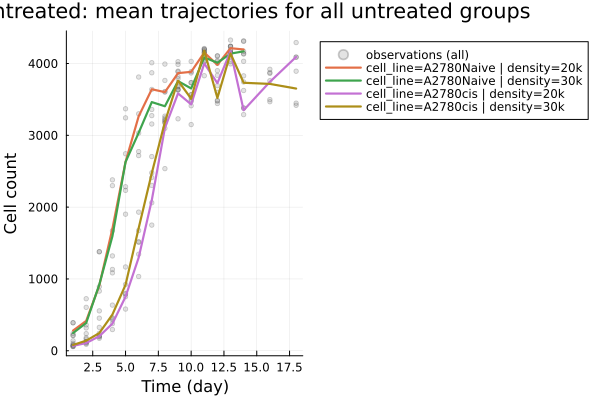

In [4]:
# Visualize decoded observations and mean trajectories across all untreated experimental groups
function choose_group_cols(df::DataFrame)
    cols = Symbol[]
    name_set = Set(Symbol.(names(df)))
    for c in (:cell_line, :density, :dose)
        if c in name_set && length(unique(df[!, c])) > 1
            push!(cols, c)
        end
    end
    if isempty(cols) && (:source_file in name_set)
        push!(cols, :source_file)
    end
    return cols
end

group_cols = choose_group_cols(decoded)

mean_df = combine(groupby(decoded, vcat(group_cols, [:time])), :count => mean => :mean_count)
sort!(mean_df, vcat(group_cols, [:time]))

obs_plot = scatter(
    decoded.time,
    decoded.count;
    alpha = 0.20,
    ms = 2.5,
    color = :gray45,
    label = "observations (all)",
    xlabel = "Time (day)",
    ylabel = "Cell count",
    title = "$(condition): mean trajectories for all untreated groups",
    legend = :outertopright,
)

for grp in groupby(mean_df, group_cols)
    lbl = join(["$(c)=$(first(grp[!, c]))" for c in group_cols], " | ")
    plot!(obs_plot, grp.time, grp.mean_count; lw = 2.2, label = lbl)
end

decoded_group_plot_path = joinpath(out.images, "$(condition)_decoded_all_groups_mean_trajectories.png")
savefig(obs_plot, decoded_group_plot_path)

mean_export_path = joinpath(out.csv, "$(condition)_decoded_all_groups_mean_trajectories.csv")
CSV.write(mean_export_path, mean_df)

MechanicalAutomaticModeling.IOUtils.write_manifest_row(
    condition = condition,
    step = "decoded-group-plot",
    outputs = [decoded_group_plot_path, mean_export_path],
    start = @__DIR__,
)

display(obs_plot)

In [5]:
required_untreated_models = [
    "logistic_growth",
    "gompertz_growth",
    "logistic_simple_death",
    "allee_growth",
    "theta_logistic_growth",
]

fit_artifacts = MechanicalAutomaticModeling.FitWorkflows.run_condition_fit!(decoded, condition; start=@__DIR__)

tested_models = sort(unique(String.(fit_artifacts.ranking.model)))
missing_models = setdiff(required_untreated_models, tested_models)

println("Tested untreated models: " * join(tested_models, ", "))
println("Missing required models: " * (isempty(missing_models) ? "none" : join(missing_models, ", ")))

Text(repr(first(fit_artifacts.ranking, min(12, nrow(fit_artifacts.ranking)))))

  Fitting logistic_growth for untreated subgroup 1...
  Fitting gompertz_growth for untreated subgroup 1...
  Fitting logistic_simple_death for untreated subgroup 1...
  Fitting allee_growth for untreated subgroup 1...
  Fitting theta_logistic_growth for untreated subgroup 1...
  Fitting logistic_growth for untreated subgroup 2...
  Fitting gompertz_growth for untreated subgroup 2...
  Fitting logistic_simple_death for untreated subgroup 2...
  Fitting allee_growth for untreated subgroup 2...
  Fitting theta_logistic_growth for untreated subgroup 2...
  Fitting logistic_growth for untreated subgroup 3...
  Fitting gompertz_growth for untreated subgroup 3...
  Fitting logistic_simple_death for untreated subgroup 3...
  Fitting allee_growth for untreated subgroup 3...
  Fitting theta_logistic_growth for untreated subgroup 3...
  Fitting logistic_growth for untreated subgroup 4...
  Fitting gompertz_growth for untreated subgroup 4...
  Fitting logistic_simple_death for untreated subgroup 

12×6 DataFrame
 Row │ model                  bic      ssr        params                             cell_line   density
     │ String                 Float64  Float64    String                             String      String
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ logistic_growth        139.491  2.03968e5  [0.7715262470516224, 4069.966384…  A2780Naive  20k
   2 │ theta_logistic_growth  142.113  2.0371e5   [0.7575043613071866, 4065.107898…  A2780Naive  20k
   3 │ logistic_simple_death  142.13   2.03968e5  [2.4474212257143573, 12910.67362…  A2780Naive  20k
   4 │ logistic_growth        147.238  3.54704e5  [0.7814694397192047, 3966.258065…  A2780Naive  30k
   5 │ theta_logistic_growth  147.768  3.05109e5  [1.1397569186757834, 4049.952080…  A2780Naive  30k
   6 │ gompertz_growth        148.495  3.88024e5  [0.403826241169591, 4196.9880488…  A2780Naive  30k
   7 │ logistic_simple_death  149.877  3.54704e5  [2.29564983631

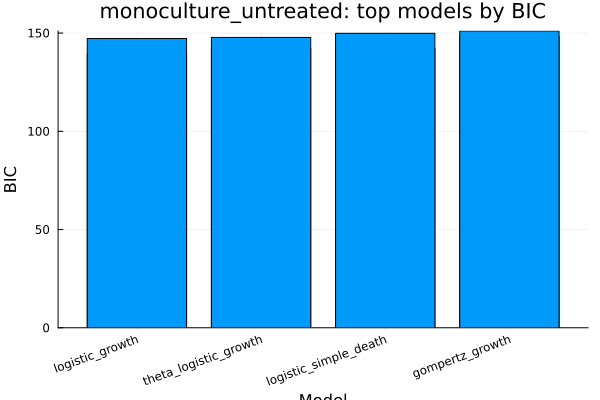

Overlay CSV is missing required columns: time, observed


In [6]:
# Visualize model quality (BIC) and model-vs-data overlay, when available
ranking_sorted = sort(fit_artifacts.ranking, :bic)
top_n = min(8, nrow(ranking_sorted))
bic_plot = bar(
    string.(ranking_sorted.model[1:top_n]),
    ranking_sorted.bic[1:top_n];
    legend = false,
    xlabel = "Model",
    ylabel = "BIC",
    title = "$(condition): top models by BIC",
    xrotation = 20,
)
display(bic_plot)

overlay_dir = joinpath(out.csv, "figures")
overlay_csvs = isdir(overlay_dir) ? sort(filter(f -> endswith(lowercase(f), "_overlay.csv"), readdir(overlay_dir; join = true))) : String[]

if isempty(overlay_csvs)
    println("No overlay CSV found in $(overlay_dir).")
else
    overlay = CSV.read(first(overlay_csvs), DataFrame)
    if !(:time in names(overlay) && :observed in names(overlay))
        println("Overlay CSV is missing required columns: time, observed")
    else
        p = scatter(
            overlay.time,
            overlay.observed;
            alpha = 0.4,
            ms = 3,
            color = :black,
            label = "observed",
            xlabel = "Time (day)",
            ylabel = "Cell count",
            title = "$(condition): model overlays",
        )

        pred_cols = filter(c -> startswith(String(c), "pred_"), names(overlay))
        plotted = 0
        for c in pred_cols
            mask = [!(ismissing(v) || (v isa AbstractFloat && isnan(v))) for v in overlay[!, c]]
            if any(mask)
                plot!(p, overlay.time[mask], overlay[mask, c]; lw = 2, label = replace(String(c), "pred_" => ""))
                plotted += 1
            end
        end

        if plotted == 0
            println("No non-missing model predictions found in overlay CSV.")
        end

        display(p)
    end
end

In [7]:
analysis_artifacts = MechanicalAutomaticModeling.AnalysisWorkflows.run_condition_analysis!(decoded, fit_artifacts, condition; start=@__DIR__)
Text(repr(analysis_artifacts.sensitivity))

1×2 DataFrame
 Row │ model            note
     │ String           String
─────┼────────────────────────────────────────────────────
   1 │ logistic_growth  Sensitivity call not available w…

In [8]:
out = MechanicalAutomaticModeling.IOUtils.condition_output_dirs(condition; start=@__DIR__)
summary = DataFrame(
    condition = [condition],
    decoded_rows = [nrow(decoded)],
    fit_rows = [nrow(fit_artifacts.ranking)],
    sensitivity_rows = [nrow(analysis_artifacts.sensitivity)],
    generated_at = [Dates.format(now(UTC), dateformat"yyyy-mm-ddTHH:MM:SS")]
)
summary_path = joinpath(out.metrics, "$(condition)_automatic_summary.csv")
CSV.write(summary_path, summary)
MechanicalAutomaticModeling.IOUtils.write_manifest_row(condition=condition, step="summary", outputs=[summary_path], start=@__DIR__)
Text(repr(summary))

1×5 DataFrame
 Row │ condition              decoded_rows  fit_rows  sensitivity_rows  generated_at
     │ String                 Int64         Int64     Int64             String
─────┼──────────────────────────────────────────────────────────────────────────────────────
   1 │ monoculture_untreated           179        20                 1  2026-04-28T04:15:10

## Final Plot: Best Fitted Model Over Data
This final cell overlays the best-BIC fitted model trajectory on top of the observed data and saves the figure to the condition image output folder.

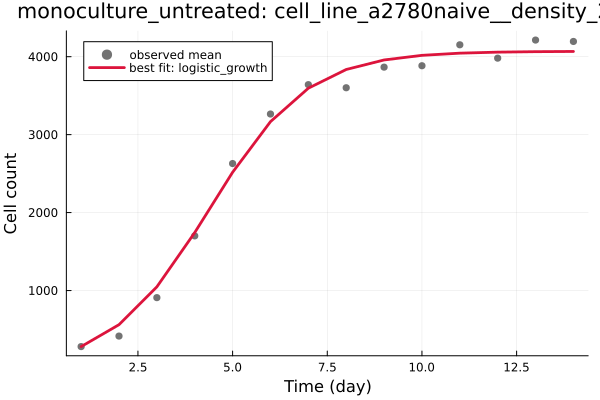

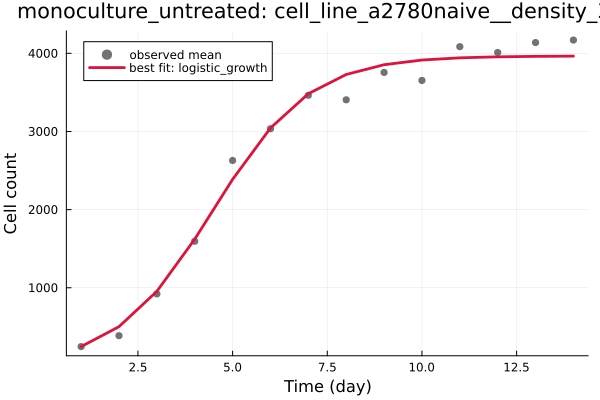

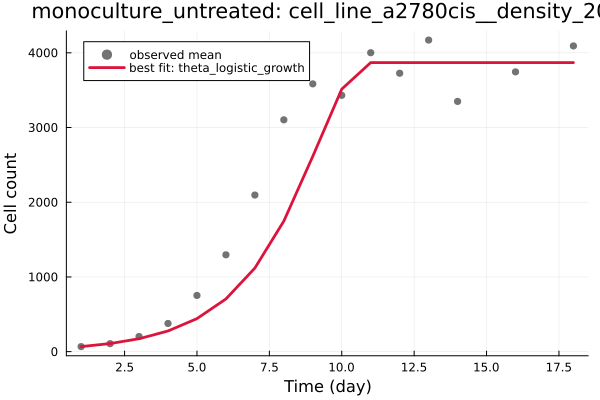

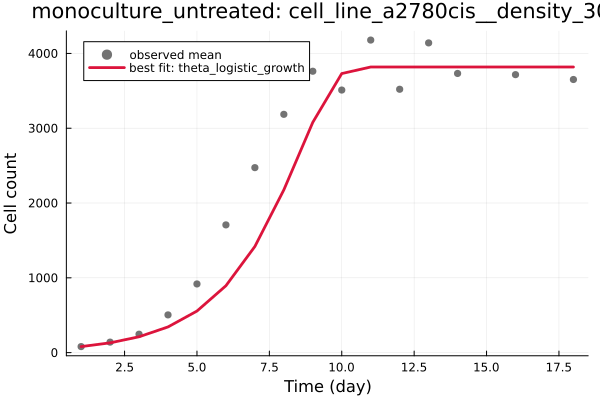

Exported group overlays: 9 files
Overlay image dir: c:\Users\elbak\Desktop\CancerGrowthDynamics\Modeling_Approaches\02_mechanical_automatic_package\outputs\images\monoculture_untreated\figures
Overlay csv dir: c:\Users\elbak\Desktop\CancerGrowthDynamics\Modeling_Approaches\02_mechanical_automatic_package\outputs\csv\monoculture_untreated\figures


In [9]:
# Final overlays: best fitted model against observations for ALL untreated experimental groups
out = MechanicalAutomaticModeling.IOUtils.condition_output_dirs(condition; start=@__DIR__)
overlay_img_dir = joinpath(out.images, "figures")
overlay_csv_dir = joinpath(out.csv, "figures")
mkpath(overlay_img_dir)
mkpath(overlay_csv_dir)

sanitize_tag(s) = replace(lowercase(string(s)), r"[^a-z0-9]+" => "_")

# Parse numeric values from the params text emitted by fitting workflow.
function parse_params(params_txt)
    [parse(Float64, m.match) for m in eachmatch(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", String(params_txt))]
end

function simulate_scalar_ode(rhs, t::Vector{Float64}, n0::Float64)
    y = zeros(Float64, length(t))
    y[1] = max(n0, 0.0)
    for i in 2:length(t)
        dt = max(t[i] - t[i - 1], 0.0)
        n_prev = max(y[i - 1], 0.0)
        y[i] = max(n_prev + dt * rhs(n_prev), 0.0)
    end
    return y
end

# Closed-form / numerical curves for supported growth models.
function model_prediction(model_name::String, params::Vector{Float64}, t::Vector{Float64}, n0::Float64)
    t0 = first(t)
    if model_name == "logistic_growth" && length(params) >= 2
        r, K = params[1], max(params[2], 1e-8)
        return [K / (1 + ((K - n0) / max(n0, 1e-8)) * exp(-r * (ti - t0))) for ti in t]
    elseif model_name == "gompertz_growth" && length(params) >= 2
        r, K = params[1], max(params[2], 1e-8)
        return [K * exp(log(max(n0, 1e-8) / K) * exp(-r * (ti - t0))) for ti in t]
    elseif model_name == "logistic_simple_death" && length(params) >= 3
        r, K, d = params[1], max(params[2], 1e-8), max(params[3], 0.0)
        return simulate_scalar_ode(n -> (r * n * max(0.0, 1 - n / K) - d * n), t, n0)
    elseif model_name == "allee_growth" && length(params) >= 3
        r, K, A = params[1], max(params[2], 1e-8), max(params[3], 1e-8)
        return simulate_scalar_ode(n -> (r * n * max(0.0, 1 - n / K) * (n / A - 1)), t, n0)
    elseif model_name == "theta_logistic_growth" && length(params) >= 3
        r, K, theta = params[1], max(params[2], 1e-8), max(params[3], 1e-8)
        return simulate_scalar_ode(n -> (r * n * max(0.0, 1 - (n / K)^theta)), t, n0)
    else
        return fill(NaN, length(t))
    end
end

function choose_group_cols(df::DataFrame)
    cols = Symbol[]
    name_set = Set(Symbol.(names(df)))
    for c in (:cell_line, :density, :dose)
        if c in name_set && length(unique(df[!, c])) > 1
            push!(cols, c)
        end
    end
    if isempty(cols) && (:source_file in name_set)
        push!(cols, :source_file)
    end
    return cols
end

group_cols = choose_group_cols(decoded)

all_overlay_frames = DataFrame[]
saved_paths = String[]

for grp in groupby(decoded, group_cols)
    key_map = Dict{Symbol,Any}(c => first(grp[!, c]) for c in group_cols)

    group_rank = fit_artifacts.ranking
    for c in (:cell_line, :density, :dose)
        if (c in Symbol.(names(group_rank))) && (c in keys(key_map))
            group_rank = filter(r -> r[c] == key_map[c], group_rank)
        end
    end

    if nrow(group_rank) == 0
        # If ranking has no subgroup columns (legacy / pooled case), reuse pooled best model.
        group_rank = fit_artifacts.ranking
    end

    best_row = first(sort(group_rank, :bic), 1)
    best_model = String(best_row.model[1])
    params_vec = parse_params(best_row.params[1])

    obs_mean = combine(groupby(grp, :time), :count => mean => :observed)
    sort!(obs_mean, :time)

    n0 = max(first(obs_mean.observed), 1e-8)
    pred = model_prediction(best_model, params_vec, Float64.(obs_mean.time), n0)

    tag = join(["$(c)_$(sanitize_tag(key_map[c]))" for c in group_cols], "__")

    overlay_df = DataFrame(
        time = obs_mean.time,
        observed = obs_mean.observed,
        prediction = pred,
        best_model = fill(best_model, nrow(obs_mean)),
    )
    for c in group_cols
        overlay_df[!, c] = fill(string(key_map[c]), nrow(obs_mean))
    end

    overlay_csv_path = joinpath(overlay_csv_dir, "$(condition)_$(tag)_best_overlay.csv")
    CSV.write(overlay_csv_path, overlay_df)
    push!(saved_paths, overlay_csv_path)
    push!(all_overlay_frames, overlay_df)

    p = scatter(
        obs_mean.time,
        obs_mean.observed;
        alpha = 0.55,
        ms = 4,
        color = :black,
        label = "observed mean",
        xlabel = "Time (day)",
        ylabel = "Cell count",
        title = "$(condition): $(tag)",
        legend = :topleft,
    )
    finite_mask = .!isnan.(pred)
    if any(finite_mask)
        plot!(p, obs_mean.time[finite_mask], pred[finite_mask]; lw = 2.8, color = :crimson, label = "best fit: $(best_model)")
    else
        annotate!(p, minimum(obs_mean.time), maximum(obs_mean.observed), text("prediction unavailable for $(best_model)", 8, :red))
    end

    overlay_img_path = joinpath(overlay_img_dir, "$(condition)_$(tag)_best_overlay.png")
    savefig(p, overlay_img_path)
    push!(saved_paths, overlay_img_path)

    # Render each group overlay in notebook output, not only save to disk.
    display(p)
end

if !isempty(all_overlay_frames)
    all_overlay_df = vcat(all_overlay_frames...)
    all_overlay_path = joinpath(overlay_csv_dir, "$(condition)_all_groups_best_overlays.csv")
    CSV.write(all_overlay_path, all_overlay_df)
    push!(saved_paths, all_overlay_path)
end

MechanicalAutomaticModeling.IOUtils.write_manifest_row(
    condition = condition,
    step = "all-group-best-overlays",
    outputs = saved_paths,
    start = @__DIR__,
)

println("Exported group overlays: $(length(saved_paths)) files")
println("Overlay image dir: $(overlay_img_dir)")
println("Overlay csv dir: $(overlay_csv_dir)")